In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

# set default chart style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("libraries imported successfully!")

libraries imported successfully!


In [16]:
# ============================================================
# connect python to sql server
# ============================================================

conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=LAPTOP-8MDS3V7U;'
    'DATABASE=stackoverflow_survey;'
    'Trusted_Connection=yes'
)

print("connected to sql server successfully!")

connected to sql server successfully!


C:\Users\Sparsh Kapoor\AppData\Local\Temp\ipykernel_21328\1634718431.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\Sparsh Kapoor\AppData\Local\Temp\ipykernel_21328\1634718431.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


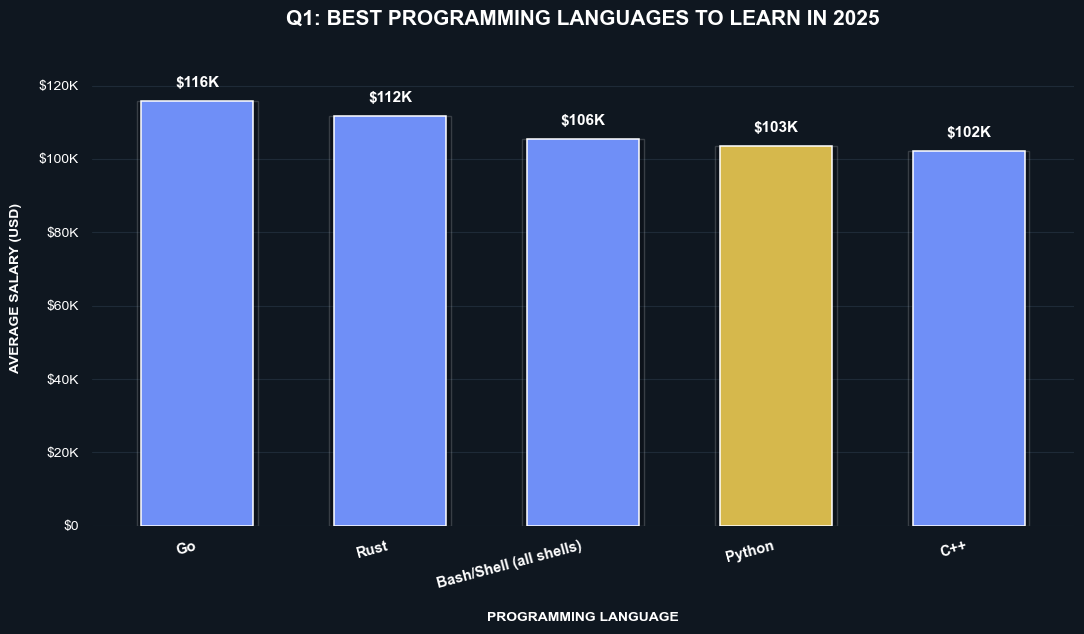

In [37]:

# 1. FETCH DATA FROM SQL
query = """
SELECT TOP 5
    TRIM(value)           AS language,
    COUNT(*)              AS total_users,
    ROUND(AVG(salary), 0) AS avg_salary
FROM clean_survey
CROSS APPLY STRING_SPLIT(languages, ';')
WHERE TRIM(value) != ''
GROUP BY TRIM(value)
HAVING COUNT(*) > 1000
ORDER BY avg_salary DESC
"""

df = pd.read_sql(query, conn)

df = df.sort_values('avg_salary', ascending=False)

# 2. DARK CANVAS
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='#0f1720')
ax.set_facecolor('#0f1720')

# 3. GRIDLINES
ax.grid(axis='y', color='#2b3a4a', linestyle='-', linewidth=0.8, alpha=0.55, zorder=0)
ax.grid(axis='x', visible=False)

# 4. COLORS
colors = []

for lang in df['language']:
    if lang == 'Python':
        colors.append('#d6b84c')
    else:
        colors.append('#6f8ff7')

# 5. SHADOW LAYER
ax.bar(
    df['language'],
    df['avg_salary'],
    color='black',
    alpha=0.18,
    width=0.63,
    zorder=1
)

# 6. MAIN BARS
bars = ax.bar(
    df['language'],
    df['avg_salary'],
    color=colors,
    width=0.58,
    edgecolor='white',
    linewidth=1.1,
    zorder=3
)

# 7. VALUE LABELS
ax.bar_label(
    bars,
    labels=[f'${x/1000:.0f}K' for x in df['avg_salary']],
    padding=8,
    fontsize=11,
    fontweight='bold',
    color='white'
)

# 8. TITLE
ax.set_title(
    "Q1: BEST PROGRAMMING LANGUAGES TO LEARN IN 2025",
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=18
)

# 9. AXIS LABELS
ax.set_ylabel(
    'AVERAGE SALARY (USD)',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=12
)

ax.set_xlabel(
    'PROGRAMMING LANGUAGE',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=15
)

# 10. X-TICKS
ax.set_xticklabels(
    df['language'],
    rotation=15,
    ha='right',
    fontsize=10.5,
    fontweight='bold',
    color='white'
)

ax.tick_params(axis='y', colors='white', labelsize=10)

# 11. Y-AXIS FORMAT
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K' if x > 0 else '$0')
)

ax.set_ylim(0, df['avg_salary'].max() * 1.12)

# 12. REMOVE BORDERS
sns.despine(left=True, bottom=True)

# 13. FINAL LAYOUT
plt.tight_layout()
plt.show()

C:\Users\Sparsh Kapoor\AppData\Local\Temp\ipykernel_21328\804231819.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


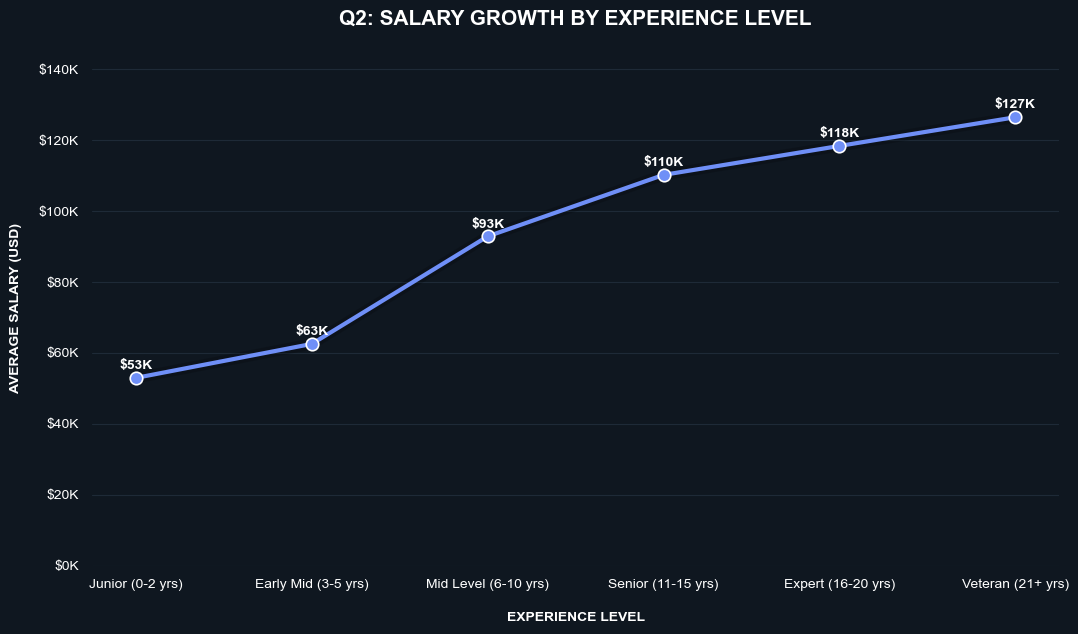

In [38]:


# =====================================
# 1. FETCH DATA FROM SQL
# =====================================

query = """
SELECT
    CASE
        WHEN experience BETWEEN 0  AND 2  THEN '1. Junior (0-2 yrs)'
        WHEN experience BETWEEN 3  AND 5  THEN '2. Early Mid (3-5 yrs)'
        WHEN experience BETWEEN 6  AND 10 THEN '3. Mid Level (6-10 yrs)'
        WHEN experience BETWEEN 11 AND 15 THEN '4. Senior (11-15 yrs)'
        WHEN experience BETWEEN 16 AND 20 THEN '5. Expert (16-20 yrs)'
        ELSE                                   '6. Veteran (21+ yrs)'
    END                   AS experience_level,
    COUNT(*)              AS total_people,
    ROUND(AVG(salary), 0) AS avg_salary
FROM clean_survey
GROUP BY
    CASE
        WHEN experience BETWEEN 0  AND 2  THEN '1. Junior (0-2 yrs)'
        WHEN experience BETWEEN 3  AND 5  THEN '2. Early Mid (3-5 yrs)'
        WHEN experience BETWEEN 6  AND 10 THEN '3. Mid Level (6-10 yrs)'
        WHEN experience BETWEEN 11 AND 15 THEN '4. Senior (11-15 yrs)'
        WHEN experience BETWEEN 16 AND 20 THEN '5. Expert (16-20 yrs)'
        ELSE                                   '6. Veteran (21+ yrs)'
    END
ORDER BY experience_level
"""

df = pd.read_sql(query, conn)

# =====================================
# 2. CLEAN LABELS
# =====================================

df['label'] = df['experience_level'].str.replace(
    r'^\d+\.\s*',
    '',
    regex=True
)

# =====================================
# 3. DARK CANVAS
# =====================================

plt.style.use('dark_background')

fig, ax = plt.subplots(
    figsize=(11, 6.5),
    facecolor='#0f1720'
)

ax.set_facecolor('#0f1720')

# =====================================
# 4. GRIDLINES
# =====================================

ax.grid(
    axis='y',
    color='#2b3a4a',
    linestyle='-',
    linewidth=0.8,
    alpha=0.55,
    zorder=0
)

ax.grid(axis='x', visible=False)

# =====================================
# 5. SHADOW LINE
# =====================================

ax.plot(
    df['label'],
    df['avg_salary'],
    color='black',
    linewidth=8,
    alpha=0.18,
    zorder=1
)

# =====================================
# 6. MAIN LINE
# =====================================

ax.plot(
    df['label'],
    df['avg_salary'],
    color='#6f8ff7',
    linewidth=3,
    marker='o',
    markersize=9,
    markerfacecolor='#6f8ff7',
    markeredgecolor='white',
    markeredgewidth=1.2,
    zorder=3
)

# =====================================
# 7. VALUE LABELS
# =====================================

for x, y in zip(df['label'], df['avg_salary']):
    ax.text(
        x,
        y + 2500,
        f'${y/1000:.0f}K',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

# =====================================
# 8. TITLE
# =====================================

ax.set_title(
    "Q2: SALARY GROWTH BY EXPERIENCE LEVEL",
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=18
)

# =====================================
# 9. AXIS LABELS
# =====================================

ax.set_ylabel(
    'AVERAGE SALARY (USD)',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=12
)

ax.set_xlabel(
    'EXPERIENCE LEVEL',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=15
)

# =====================================
# 10. TICKS
# =====================================

ax.tick_params(
    axis='x',
    colors='white',
    labelsize=10
)

ax.tick_params(
    axis='y',
    colors='white',
    labelsize=10
)

# =====================================
# 11. Y-AXIS FORMAT
# =====================================

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f'${x*1e-3:.0f}K'
    )
)

ax.set_ylim(0, df['avg_salary'].max() * 1.15)

# =====================================
# 12. REMOVE BORDERS
# =====================================

sns.despine(
    left=True,
    bottom=True
)

# =====================================
# 13. FINAL LAYOUT
# =====================================

plt.tight_layout()
plt.show()

C:\Users\Sparsh Kapoor\AppData\Local\Temp\ipykernel_21328\843090713.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


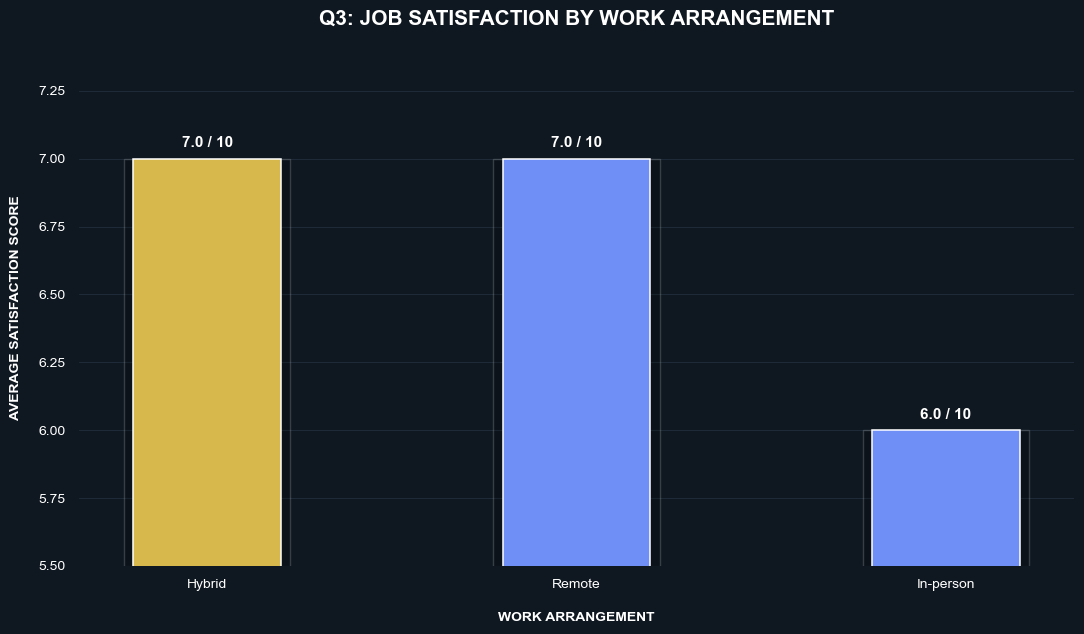

In [39]:

# =====================================
# 1. FETCH DATA FROM SQL
# =====================================

query = """
SELECT
    remote_work,
    COUNT(*)                        AS total_people,
    ROUND(AVG(job_satisfaction), 1) AS avg_satisfaction
FROM clean_survey
WHERE remote_work IS NOT NULL
GROUP BY remote_work
ORDER BY avg_satisfaction DESC
"""

df = pd.read_sql(query, conn)

# =====================================
# 2. DARK CANVAS
# =====================================

plt.style.use('dark_background')

fig, ax = plt.subplots(
    figsize=(11, 6.5),
    facecolor='#0f1720'
)

ax.set_facecolor('#0f1720')

# =====================================
# 3. GRIDLINES
# =====================================

ax.grid(
    axis='y',
    color='#2b3a4a',
    linestyle='-',
    linewidth=0.8,
    alpha=0.55,
    zorder=0
)

ax.grid(axis='x', visible=False)

# =====================================
# 4. COLORS
# Highlight the best arrangement
# =====================================

best_arrangement = df.iloc[0]['remote_work']

colors = []

for arrangement in df['remote_work']:
    if arrangement == best_arrangement:
        colors.append('#d6b84c')      # Gold highlight
    else:
        colors.append('#6f8ff7')      # Blue

# =====================================
# 5. SHADOW LAYER
# =====================================

ax.bar(
    df['remote_work'],
    df['avg_satisfaction'],
    color='black',
    alpha=0.18,
    width=0.45,
    zorder=1
)

# =====================================
# 6. MAIN BARS
# =====================================

bars = ax.bar(
    df['remote_work'],
    df['avg_satisfaction'],
    color=colors,
    width=0.40,
    edgecolor='white',
    linewidth=1.1,
    zorder=3
)

# =====================================
# 7. VALUE LABELS
# =====================================

ax.bar_label(
    bars,
    labels=[f'{x:.1f} / 10' for x in df['avg_satisfaction']],
    padding=6,
    fontsize=11,
    fontweight='bold',
    color='white'
)

# =====================================
# 8. TITLE
# =====================================

ax.set_title(
    "Q3: JOB SATISFACTION BY WORK ARRANGEMENT",
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=18
)

# =====================================
# 9. AXIS LABELS
# =====================================

ax.set_ylabel(
    'AVERAGE SATISFACTION SCORE',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=12
)

ax.set_xlabel(
    'WORK ARRANGEMENT',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=15
)

# =====================================
# 10. TICKS
# =====================================

ax.tick_params(
    axis='x',
    colors='white',
    labelsize=10
)

ax.tick_params(
    axis='y',
    colors='white',
    labelsize=10
)

# =====================================
# 11. ZOOMED Y-AXIS
# =====================================

y_min = max(0, df['avg_satisfaction'].min() - 0.5)
y_max = df['avg_satisfaction'].max() + 0.4

ax.set_ylim(y_min, y_max)

# =====================================
# 12. REMOVE BORDERS
# =====================================

sns.despine(
    left=True,
    bottom=True
)

# =====================================
# 13. FINAL LAYOUT
# =====================================

plt.tight_layout()
plt.show()

C:\Users\Sparsh Kapoor\AppData\Local\Temp\ipykernel_21328\3046828876.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


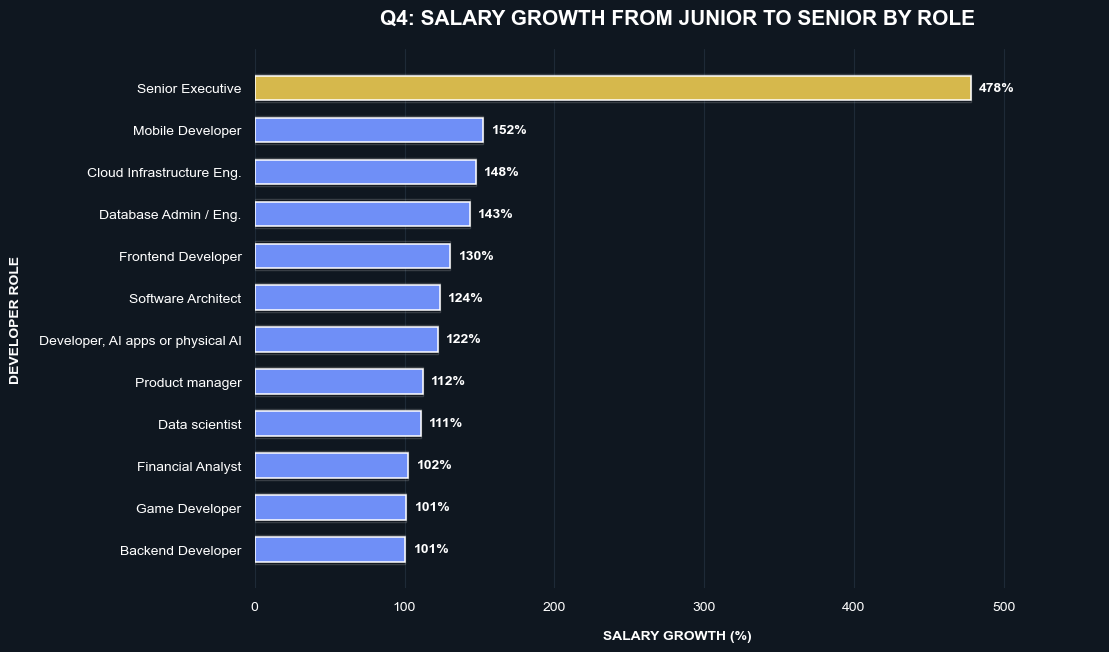

In [42]:


# =====================================
# 1. FETCH DATA FROM SQL
# =====================================

query = """
WITH junior AS (
    SELECT devtype, ROUND(AVG(salary), 0) AS junior_salary
    FROM clean_survey
    WHERE experience <= 5
    GROUP BY devtype
),
senior AS (
    SELECT devtype, ROUND(AVG(salary), 0) AS senior_salary
    FROM clean_survey
    WHERE experience > 10
    GROUP BY devtype
)
SELECT TOP 12
    j.devtype AS developer_role,
    j.junior_salary,
    s.senior_salary,
    ROUND(((CAST(s.senior_salary AS FLOAT) - CAST(j.junior_salary AS FLOAT))
           / CAST(j.junior_salary AS FLOAT)) * 100, 1) AS growth_pct
FROM junior j
JOIN senior s
    ON j.devtype = s.devtype
ORDER BY growth_pct DESC
"""

df = pd.read_sql(query, conn)

# =====================================
# 2. CLEAN ROLE NAMES
# =====================================

df['role'] = df['developer_role'].replace({
    'Senior executive (C-suite, VP, etc.)': 'Senior Executive',
    'Cloud infrastructure engineer': 'Cloud Infrastructure Eng.',
    'Database administrator or engineer': 'Database Admin / Eng.',
    'Architect, software or solutions': 'Software Architect',
    'Developer, AI apps or physical systems': 'AI Developer',
    'Financial analyst or engineer': 'Financial Analyst',
    'Developer, game or graphics': 'Game Developer',
    'Developer, back-end': 'Backend Developer',
    'Developer, front-end': 'Frontend Developer',
    'Developer, mobile': 'Mobile Developer'
})

df = df.sort_values('growth_pct', ascending=True)

# =====================================
# 3. DARK CANVAS
# =====================================

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(13, 7), facecolor='#0f1720')
ax.set_facecolor('#0f1720')

# =====================================
# 4. GRIDLINES
# =====================================

ax.grid(axis='x', color='#2b3a4a', linestyle='-', linewidth=0.8, alpha=0.55, zorder=0)
ax.grid(axis='y', visible=False)

# =====================================
# 5. COLORS
# =====================================

highest_growth = df['growth_pct'].max()

colors = []

for growth in df['growth_pct']:
    if growth == highest_growth:
        colors.append('#d6b84c')
    else:
        colors.append('#6f8ff7')

# =====================================
# 6. SHADOW LAYER
# =====================================

ax.barh(
    df['role'],
    df['growth_pct'],
    color='black',
    alpha=0.18,
    height=0.68,
    zorder=1
)

# =====================================
# 7. MAIN BARS
# =====================================

bars = ax.barh(
    df['role'],
    df['growth_pct'],
    color=colors,
    height=0.58,
    edgecolor='white',
    linewidth=1.1,
    zorder=3
)

# =====================================
# 8. VALUE LABELS
# =====================================

ax.bar_label(
    bars,
    labels=[f'{x:.0f}%' for x in df['growth_pct']],
    padding=6,
    fontsize=10,
    fontweight='bold',
    color='white'
)

# =====================================
# 9. TITLE
# =====================================

ax.set_title(
    "Q4: SALARY GROWTH FROM JUNIOR TO SENIOR BY ROLE",
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=18
)

# =====================================
# 10. AXIS LABELS
# =====================================

ax.set_xlabel(
    'SALARY GROWTH (%)',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=12
)

ax.set_ylabel(
    'DEVELOPER ROLE',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=12
)

# =====================================
# 11. TICKS
# =====================================

ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

# =====================================
# 12. X-AXIS LIMIT
# =====================================

ax.set_xlim(0, df['growth_pct'].max() * 1.18)

# =====================================
# 13. REMOVE BORDERS
# =====================================

sns.despine(left=True, bottom=True)

# =====================================
# 14. FIX LEFT MARGIN
# =====================================

plt.subplots_adjust(left=0.25)

# =====================================
# 15. FINAL LAYOUT
# =====================================

plt.show()

C:\Users\Sparsh Kapoor\AppData\Local\Temp\ipykernel_21328\3954567062.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\Sparsh Kapoor\AppData\Local\Temp\ipykernel_21328\3954567062.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


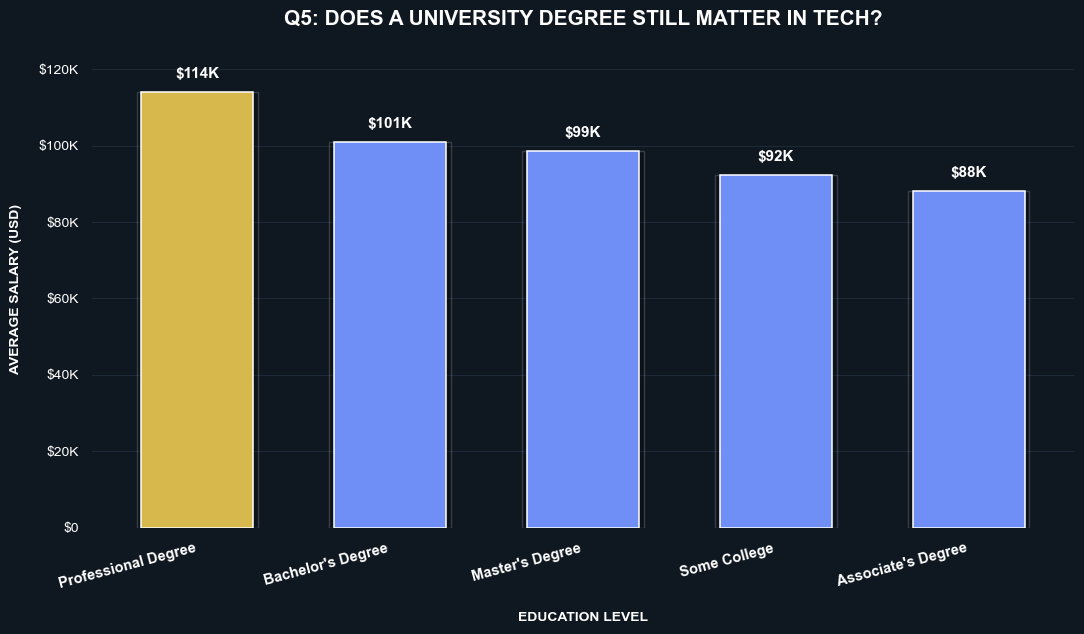

In [ ]:



#  FETCH DATA FROM SQL


query = """
SELECT
    education,
    COUNT(*)              AS total_people,
    ROUND(AVG(salary), 0) AS avg_salary
FROM clean_survey
GROUP BY education
ORDER BY avg_salary DESC
"""

df = pd.read_sql(query, conn)

# =====================================
# 2. CLEAN LABELS
# =====================================

df['edu_label'] = df['education']

df.loc[df['education'].str.contains("Bachelor", na=False), 'edu_label'] = "Bachelor's Degree"

df.loc[df['education'].str.contains("Master", na=False), 'edu_label'] = "Master's Degree"

df.loc[df['education'].str.contains("Professional", na=False), 'edu_label'] = "Professional Degree"

df.loc[df['education'].str.contains("Associate", na=False), 'edu_label'] = "Associate's Degree"

df.loc[df['education'].str.contains("Some college", na=False), 'edu_label'] = "Some College"

df.loc[df['education'].str.contains("doctoral", na=False), 'edu_label'] = "PhD"

df.loc[df['education'].str.contains("formal education", na=False), 'edu_label'] = "No Degree"

df = df.sort_values('avg_salary', ascending=False)

# =====================================
# 3. DARK CANVAS
# =====================================

plt.style.use('dark_background')

fig, ax = plt.subplots(
    figsize=(11, 6.5),
    facecolor='#0f1720'
)

ax.set_facecolor('#0f1720')

# =====================================
# 4. GRIDLINES
# =====================================

ax.grid(
    axis='y',
    color='#2b3a4a',
    linestyle='-',
    linewidth=0.8,
    alpha=0.55,
    zorder=0
)

ax.grid(axis='x', visible=False)

# =====================================
# 5. COLORS
# =====================================

colors = []

for label in df['edu_label']:
    if label == "Professional Degree":
        colors.append('#d6b84c')  # Gold Highlight
    else:
        colors.append('#6f8ff7')  # Blue

# =====================================
# 6. SHADOW LAYER
# =====================================

ax.bar(
    df['edu_label'],
    df['avg_salary'],
    color='black',
    alpha=0.18,
    width=0.63,
    zorder=1
)

# =====================================
# 7. MAIN BARS
# =====================================

bars = ax.bar(
    df['edu_label'],
    df['avg_salary'],
    color=colors,
    width=0.58,
    edgecolor='white',
    linewidth=1.1,
    zorder=3
)

# =====================================
# 8. BAR LABELS
# =====================================

ax.bar_label(
    bars,
    labels=[f'${x/1000:.0f}K' for x in df['avg_salary']],
    padding=8,
    fontsize=11,
    fontweight='bold',
    color='white'
)

# =====================================
# 9. TITLE
# =====================================

ax.set_title(
    "Q5: DOES A UNIVERSITY DEGREE STILL MATTER IN TECH?",
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=18
)

# =====================================
# 10. AXIS LABELS
# =====================================

ax.set_ylabel(
    'AVERAGE SALARY (USD)',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=12
)

ax.set_xlabel(
    'EDUCATION LEVEL',
    fontsize=10,
    fontweight='bold',
    color='white',
    labelpad=15
)

# =====================================
# 11. X-TICKS
# =====================================

ax.set_xticklabels(
    df['edu_label'],
    rotation=15,
    ha='right',
    fontsize=10.5,
    fontweight='bold',
    color='white'
)

ax.tick_params(
    axis='y',
    colors='white',
    labelsize=10
)

# =====================================
# 12. Y-AXIS FORMAT
# =====================================

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f'${x*1e-3:.0f}K' if x > 0 else '$0'
    )
)

ax.set_ylim(0, 125000)

# =====================================
# 13. REMOVE BORDERS
# =====================================

sns.despine(
    left=True,
    bottom=True
)

# =====================================
# 14. FINAL LAYOUT
# =====================================

plt.tight_layout()
plt.show()